# Ouvidoria Inteligente — Detecção de Duplicatas Semânticas

Este notebook utiliza embeddings e similaridade de cosseno para identificar manifestações semanticamente semelhantes na base da Ouvidoria Inteligente.

O objetivo é construir uma função de detecção de duplicatas, analisar os pares encontrados a partir de um limiar de similaridade e avaliar possíveis falsos positivos e falsos negativos.

In [93]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [94]:
caminho_json = Path("../manifestacoes.json")

with open(caminho_json, "r", encoding="utf-8") as arquivo:
    manifestacoes = json.load(arquivo)

df = pd.DataFrame(manifestacoes)

print(f"Total de manifestações: {len(df)}")

df.head()

Total de manifestações: 40


,id,data,categoria_oficial,texto
0,M001,2026-08-01,infraestrutura,"Há um buraco profundo na Rua das Palmeiras, pr..."
1,M002,2026-08-02,educação,A escola municipal do bairro Jardim Novo está ...
2,M003,2026-08-03,infraestrutura,"Existe um buraco enorme na Av. Brasil, perto d..."
3,M004,2026-08-04,meio ambiente,Moradores estão descartando lixo e entulho às ...
4,M005,2026-08-05,segurança,A praça do bairro Primavera fica muito escura ...


In [95]:
print("Dimensões:", df.shape)
print("\nColunas:", df.columns.tolist())

print("\nValores nulos:")
print(df.isnull().sum())

print("\nQuantidade por categoria:")
print(df["categoria_oficial"].value_counts())

Dimensões: (40, 4)

Colunas: ['id', 'data', 'categoria_oficial', 'texto']

Valores nulos:
id                   0
data                 0
categoria_oficial    0
texto                0
dtype: int64

Quantidade por categoria:
categoria_oficial
infraestrutura    11
educação           8
meio ambiente      8
saúde              7
segurança          6
Name: count, dtype: int64


In [96]:
textos = df["texto"].tolist()

modelo_nome = "paraphrase-multilingual-MiniLM-L12-v2"

modelo = SentenceTransformer(modelo_nome)

print("Modelo carregado:", modelo_nome)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo carregado: paraphrase-multilingual-MiniLM-L12-v2


In [97]:
embeddings = modelo.encode(
    textos,
    convert_to_numpy=True
)

print("Formato dos embeddings:", embeddings.shape)

Formato dos embeddings: (40, 384)


In [98]:
matriz_similaridade = cosine_similarity(embeddings)

print("Formato da matriz de similaridade:", matriz_similaridade.shape)

matriz_similaridade

Formato da matriz de similaridade: (40, 40)


array([[1.0000001 , 0.14169352, 0.74010646, ..., 0.39489073, 0.14870137,
        0.3967912 ],
       [0.14169352, 1.0000002 , 0.0695644 , ..., 0.33148268, 0.44657594,
        0.28567165],
       [0.74010646, 0.0695644 , 1.0000001 , ..., 0.41728526, 0.16100308,
        0.3161289 ],
       ...,
       [0.39489073, 0.33148268, 0.41728526, ..., 0.99999976, 0.3716123 ,
        0.20380694],
       [0.14870137, 0.44657594, 0.16100308, ..., 0.3716123 , 1.0000001 ,
        0.17278853],
       [0.3967912 , 0.28567165, 0.3161289 , ..., 0.20380694, 0.17278853,
        0.9999999 ]], shape=(40, 40), dtype=float32)

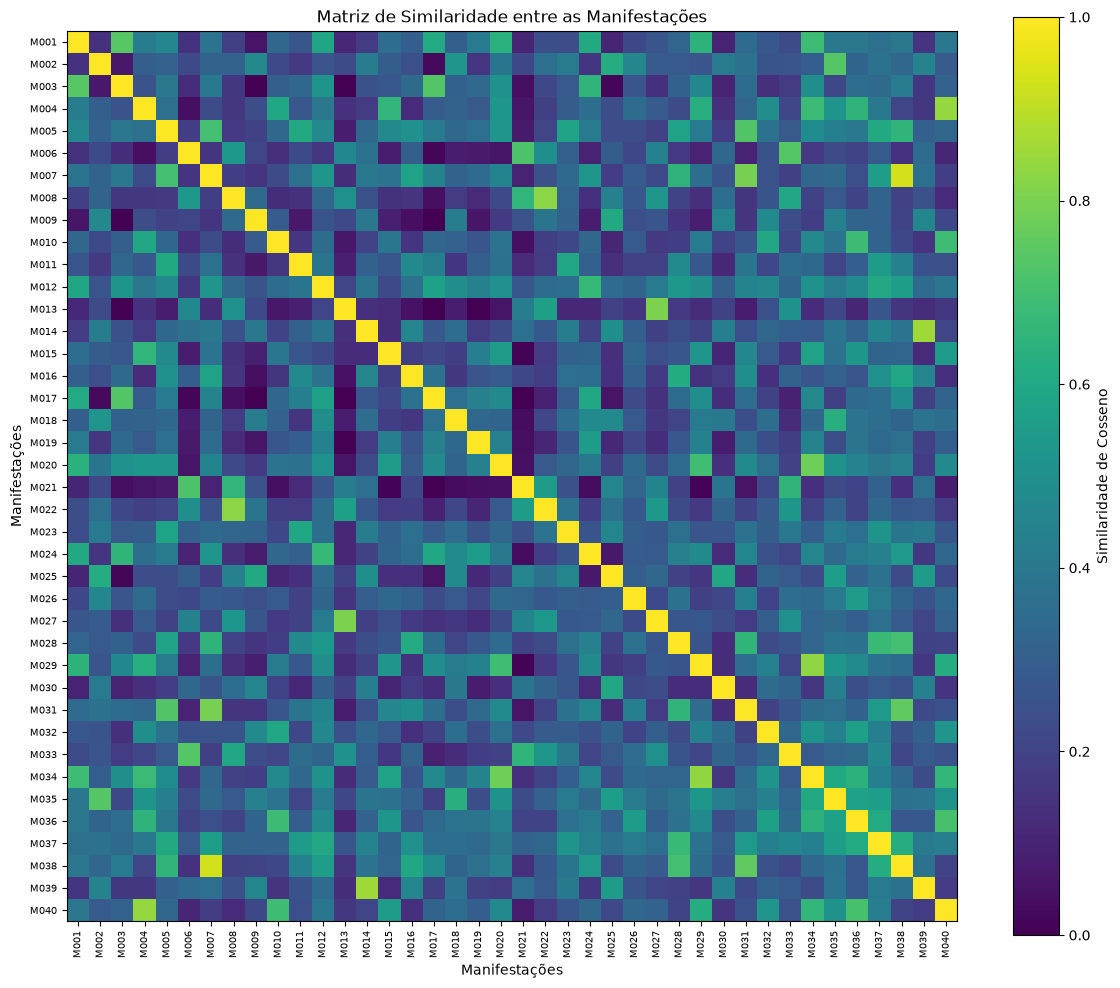

In [99]:
plt.figure(figsize=(12, 10))

plt.imshow(
    matriz_similaridade,
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Similaridade de Cosseno")

plt.xticks(
    range(len(df)),
    df["id"],
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(df)),
    df["id"],
    fontsize=7
)

plt.title("Matriz de Similaridade entre as Manifestações")
plt.xlabel("Manifestações")
plt.ylabel("Manifestações")

plt.tight_layout()
plt.show()

In [100]:
def detectar_duplicatas(textos, limiar=0.85):
    embeddings_textos = modelo.encode(
        textos,
        convert_to_numpy=True
    )

    similaridades = cosine_similarity(embeddings_textos)

    duplicatas = []

    for i in range(len(textos)):
        for j in range(i + 1, len(textos)):
            if similaridades[i][j] >= limiar:
                duplicatas.append({
                    "indice_1": i,
                    "indice_2": j,
                    "similaridade": similaridades[i][j]
                })

    return duplicatas

In [101]:
limiar = 0.85

duplicatas = detectar_duplicatas(
    textos,
    limiar=limiar
)

print(f"Limiar utilizado: {limiar}")
print(f"Quantidade de pares encontrados: {len(duplicatas)}")

Limiar utilizado: 0.85
Quantidade de pares encontrados: 2


In [102]:
resultados_duplicatas = []

for duplicata in duplicatas:
    i = duplicata["indice_1"]
    j = duplicata["indice_2"]

    resultados_duplicatas.append({
        "ID 1": df.iloc[i]["id"],
        "ID 2": df.iloc[j]["id"],
        "Similaridade": duplicata["similaridade"],
        "Texto 1": df.iloc[i]["texto"],
        "Texto 2": df.iloc[j]["texto"]
    })

df_duplicatas = pd.DataFrame(resultados_duplicatas)

if not df_duplicatas.empty:
    df_duplicatas["Similaridade"] = (
        df_duplicatas["Similaridade"].round(3)
    )

df_duplicatas

,ID 1,ID 2,Similaridade,Texto 1,Texto 2
0,M007,M038,0.931,O poste de iluminação da Rua do Sol está apaga...,A iluminação da Rua do Sol continua apresentan...
1,M014,M039,0.858,O transporte escolar da zona rural tem apresen...,O ônibus que atende os estudantes da zona rura...


In [103]:
duplicatas_reais = {
    tuple(sorted(par))
    for par in [
        ("M003", "M017"),
        ("M007", "M038"),
        ("M008", "M022"),
        ("M013", "M027"),
        ("M014", "M039"),
        ("M004", "M040")
    ]
}

print("Quantidade de duplicatas reais:", len(duplicatas_reais))

for par in sorted(duplicatas_reais):
    print(f"{par[0]} × {par[1]}")

Quantidade de duplicatas reais: 6
M003 × M017
M004 × M040
M007 × M038
M008 × M022
M013 × M027
M014 × M039


In [104]:
duplicatas_detectadas = {
    tuple(sorted((df.iloc[d["indice_1"]]["id"], df.iloc[d["indice_2"]]["id"])))
    for d in duplicatas
}

verdadeiros_positivos = duplicatas_detectadas & duplicatas_reais
falsos_positivos = duplicatas_detectadas - duplicatas_reais
falsos_negativos = duplicatas_reais - duplicatas_detectadas

print("Verdadeiros positivos:")
print(sorted(verdadeiros_positivos))

print("\nFalsos positivos:")
print(sorted(falsos_positivos))

print("\nFalsos negativos:")
print(sorted(falsos_negativos))

Verdadeiros positivos:
[('M007', 'M038'), ('M014', 'M039')]

Falsos positivos:
[]

Falsos negativos:
[('M003', 'M017'), ('M004', 'M040'), ('M008', 'M022'), ('M013', 'M027')]


In [105]:
resumo = pd.DataFrame({
    "Classificação": [
        "Verdadeiros positivos",
        "Falsos positivos",
        "Falsos negativos"
    ],
    "Quantidade": [
        len(verdadeiros_positivos),
        len(falsos_positivos),
        len(falsos_negativos)
    ]
})

resumo

,Classificação,Quantidade
0,Verdadeiros positivos,2
1,Falsos positivos,0
2,Falsos negativos,4


In [106]:
resultados_reais = []

for id1, id2 in sorted(duplicatas_reais):
    idx1 = df.index[df["id"] == id1][0]
    idx2 = df.index[df["id"] == id2][0]

    similaridade = matriz_similaridade[idx1][idx2]

    resultados_reais.append({
        "Par": f"{id1} × {id2}",
        "Similaridade": round(float(similaridade), 3),
        "Detectado": "Sim" if similaridade >= limiar else "Não"
    })

df_duplicatas_reais = pd.DataFrame(resultados_reais)

df_duplicatas_reais

,Par,Similaridade,Detectado
0,M003 × M017,0.732,Não
1,M004 × M040,0.840,Não
2,M007 × M038,0.931,Sim
3,M008 × M022,0.827,Não
4,M013 × M027,0.803,Não
5,M014 × M039,0.858,Sim


In [107]:
limiares_teste = [0.70, 0.75, 0.80, 0.85, 0.90]

resultados_limiares = []

for limiar_teste in limiares_teste:
    pares_detectados = set()

    for i in range(len(df)):
        for j in range(i + 1, len(df)):
            if matriz_similaridade[i][j] >= limiar_teste:
                par = tuple(sorted((
                    df.iloc[i]["id"],
                    df.iloc[j]["id"]
                )))
                pares_detectados.add(par)

    vp = len(pares_detectados & duplicatas_reais)
    fp = len(pares_detectados - duplicatas_reais)
    fn = len(duplicatas_reais - pares_detectados)

    resultados_limiares.append({
        "Limiar": limiar_teste,
        "Pares detectados": len(pares_detectados),
        "Verdadeiros positivos": vp,
        "Falsos positivos": fp,
        "Falsos negativos": fn
    })

df_limiares = pd.DataFrame(resultados_limiares)

df_limiares

,Limiar,Pares detectados,Verdadeiros positivos,Falsos positivos,Falsos negativos
0,0.70,18,6,12,0
1,0.75,9,5,4,1
2,0.80,6,5,1,1
3,0.85,2,2,0,4
4,0.90,1,1,0,5


In [108]:
duplicatas_080 = detectar_duplicatas(textos, limiar=0.80)

pares_080 = {
    tuple(sorted((
        df.iloc[d["indice_1"]]["id"],
        df.iloc[d["indice_2"]]["id"]
    )))
    for d in duplicatas_080
}

falsos_positivos_080 = pares_080 - duplicatas_reais
falsos_negativos_080 = duplicatas_reais - pares_080

print("Falsos positivos com limiar 0.80:")
print(sorted(falsos_positivos_080))

print("\nFalsos negativos com limiar 0.80:")
print(sorted(falsos_negativos_080))

Falsos positivos com limiar 0.80:
[('M029', 'M034')]

Falsos negativos com limiar 0.80:
[('M003', 'M017')]


## Análise dos Resultados

Com o limiar padrão de **0,85**, foram detectadas 2 das 6 duplicatas conhecidas, sem falsos positivos, mas com 4 falsos negativos. Isso indica que o valor é bastante restritivo.

Ao testar outros limiares, **0,80 apresentou o melhor equilíbrio para esta base**, identificando 5 das 6 duplicatas, com apenas 1 falso positivo e 1 falso negativo. O falso positivo foi o par **M029 × M034**, enquanto **M003 × M017** não foi identificado.